In [1]:
# import pickle

# pose = True
# with open("data.pkl", "wb") as f:
#     pickle.dump(pose, f)

# with open("data.pkl", "rb") as f:
#     pose = pickle.load(f)
# pose

In [6]:
import mediapipe as mp
import cv2
import numpy as np

In [7]:
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from collections import deque

def calculate_loss(predicted, actual):
    mae_loss = nn.MSELoss()
    loss = mae_loss(torch.tensor(predicted),torch.tensor(actual))
    return loss.item()

def calculate_angle(a, b, c):
    a = np.array(a)  # First
    b = np.array(b)  # Mid
    c = np.array(c)  # End
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
# Load the LSTM model

lstm_model = torch.jit.load(r'model_path\model_squats_scripted.pt')#for linux relative path
lstm_model.to(device) 
lstm_model.eval()
# Initialize MediaPipe pose
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Video Capture
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

# Variables for counting and tracking
stage = ""
counter = 0

# Scaling angles
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array([[0] * 7, [180] * 7]))


input_window= 20
output_window = 5
pred_freq = 5

# Store pose sequences
pose_sequences = deque(maxlen=input_window )
real_time_storage = []
frame_count = 0
collecting_real_time = False #this is a flag.false-during prediction, true-calculating real time values. 
predicted_vs_real_storage = [] 
focus_angles=[]
realtime_loss = []
run_buffer=[]
loss_buffer=[]
threshold=300
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False
        
        # Detect pose
        results = pose.process(image)
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark

            # Draw pose landmarks
            mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                      mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
                                      mp_drawing.DrawingSpec(color=(0,0,255), thickness=2, circle_radius=2))

            # Define angles to calculate
            angles_to_calculate = {
                "right_elbow_right_shoulder_right_hip": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                ],
                "left_elbow_left_shoulder_left_hip": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                ],
                "right_knee_mid_hip_left_knee": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [(landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x) / 2,
                     (landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y + landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y) / 2],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                ],
                "right_hip_right_knee_right_ankle": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ANKLE.value].y],
                ],
                "left_hip_left_knee_left_ankle": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ANKLE.value].y],
                ],
                "right_wrist_right_elbow_right_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.RIGHT_SHOULDER.value].y],
                ],
                "left_wrist_left_elbow_left_shoulder": [
                    [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y],
                    [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x, 
                     landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y],
                ],
            }

            # Compute angles
            angles = [calculate_angle(*angles_to_calculate[key]) for key in angles_to_calculate]
            print(f"Calculated Angles: {angles}")

            # Input is normalized and added to sequence
            normalized_angles = scaler.transform([angles])
            pose_sequences.append(normalized_angles[0])
            
            # Collecting real-time frames(it checks if 20 new angles are appended,later forms paird of predictions and their actual angles)
            if collecting_real_time:#if flag is true
                real_time_storage.append(angles)
                frame_count += 1  # Count frames collected
                if frame_count == output_window:  # Ensure it's the same number as predicted
                    # Store the actual vs predicted values correctly
                    predicted_vs_real_storage.append((predicted_angles.copy(), real_time_storage.copy())) 

                    # Extract key angles for evaluation
                    predicted_focus = [[list(pred[3:5]) for pred in group[0]] for group in predicted_vs_real_storage]  
                    real_focus = [[list(real[3:5])for real in group[1]] for group in predicted_vs_real_storage]  

                    focus_angles = list(zip(predicted_focus, real_focus))
                    realtime_loss.append(calculate_loss(predicted=focus_angles[-1][0], actual=focus_angles[-1][1]))

                    run_buffer.append(focus_angles[-1][1])
                    if len(run_buffer)> 3:
                        run_buffer.pop(0)

                    loss_buffer.append(realtime_loss[-1])
                    if len(loss_buffer) > 3:
                        loss_buffer.pop(0)
        
                    # Reset collection
                    collecting_real_time = False  
                    real_time_storage = []  
                    frame_count = 0 
                    
            # Prediction
            if len(pose_sequences) == input_window  and not collecting_real_time:# if flag is false
                input_window_degrees = scaler.inverse_transform(np.array(pose_sequences))
                print(f" Input Window (Degrees) Before Prediction:\n{input_window_degrees}") 
                input_seq = torch.tensor([pose_sequences], dtype=torch.float32).to(device)
                with torch.no_grad():
                    predicted_normalized = lstm_model(input_seq).cpu().numpy().squeeze(0)
                predicted_angles = scaler.inverse_transform(predicted_normalized)
                
                print(f"Predicted Angles:{predicted_angles}")
                real_time_storage = []  
                collecting_real_time = True  
                frame_count = 0 
                
                # Sliding window for input
                pose_sequences = deque(list(pose_sequences)[pred_freq:], maxlen=input_window)#removes previous 20 frames
                pose_sequences.extend(real_time_storage[:pred_freq])#appends new 20 frames to remaining 30 frames
                real_time_storage = []  
                collecting_real_time = True  
                
                # i have not focused on camera written display 
                for i, angle in enumerate(predicted_angles[0]):
                    cv2.putText(image, f'Predicted {i+1}: {int(angle)}', (50, 300 + i * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Show output
        cv2.imshow('Pose Estimation', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):

            break

cap.release()
cv2.destroyAllWindows()

Calculated Angles: [25.19884793010811, 74.7613454646823, 18.427858228792847, 178.55144833152752, 177.78526571754813, 162.38730080412634, 159.24864294266752]
Calculated Angles: [19.413737640824387, 57.63443477354818, 44.392532405264014, 179.90463172054615, 173.54875571189777, 170.75836425519418, 154.8400169921629]
Calculated Angles: [25.20835824174949, 52.067715991392426, 40.58786212681042, 4.347013475344131, 23.51643090548226, 172.332401318286, 149.4083504231177]
Calculated Angles: [27.342772125084576, 55.218418323644386, 117.12571305804997, 57.16044036999541, 171.00511172564103, 169.0167013784063, 152.0088494750556]
Calculated Angles: [27.501227211890487, 59.99639681286516, 23.164890810545746, 172.5589930569335, 177.61305188289472, 168.2959988644825, 161.9506654780315]
Calculated Angles: [27.9441363414177, 63.83778492884006, 18.341996280798803, 176.0281740396628, 178.65708424616327, 165.70428998803848, 148.77229899313917]
Calculated Angles: [25.684239439521424, 49.22151419573654, 19.3

c:\Users\Siddhi Shetty\.conda\envs\test_env\Lib\site-packages\torch\nn\modules\module.py:1747: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  return forward_call(*args, **kwargs)


Calculated Angles: [80.323735139203, 78.0409488136959, 17.58531945713058, 178.7984212058293, 179.7198664543834, 59.72318386944551, 54.308035306131735]
Calculated Angles: [88.33328623693514, 81.83902679971177, 17.135957138756453, 179.08600774075052, 179.67376219341313, 64.45378381228178, 54.74710002105938]
Calculated Angles: [88.76831755294809, 79.97927193985463, 17.27879878315125, 179.48807132911566, 179.7020788261219, 63.99180068617121, 51.7152008737866]
Calculated Angles: [88.90590146448831, 79.60594020571982, 17.314731482150343, 179.18558437640206, 179.80717145320375, 62.63903525523147, 50.80073841833715]
 Input Window (Degrees) Before Prediction:
[[ 27.94413634  63.83778493  18.34199628 176.02817404 178.65708425
  165.70428999 148.77229899]
 [ 25.68423944  49.2215142   19.36296491 177.8978234  179.67418587
  164.4147822  145.44924385]
 [ 26.40112067  45.31965055  17.84516448 179.22193422 177.61352582
  164.09508235 146.73671549]
 [ 28.9008689   44.93723306  17.12951421 178.24730174

c:\Users\Siddhi Shetty\.conda\envs\test_env\Lib\site-packages\torch\nn\modules\module.py:1747: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  return forward_call(*args, **kwargs)


Calculated Angles: [96.04548386528558, 82.14329326648138, 16.604198431208964, 178.8821167663052, 179.4233700615867, 68.13420460170454, 52.61585229803107]
Calculated Angles: [98.39364197809635, 85.42521162459911, 16.579014342910938, 179.26326256893643, 179.45233805532598, 70.45725812711242, 55.28385178704404]
Calculated Angles: [98.88344476123882, 85.23373601394066, 16.535882244823583, 179.49937365644212, 179.4299975585603, 71.28850897642262, 55.24976807806033]
 Input Window (Degrees) Before Prediction:
[[ 28.7286907   39.6780416   14.52120296 176.15563255 178.40527856
  163.80528244 153.21772931]
 [ 27.14368458  35.03208838  15.32496161 177.3016579  178.35023676
  161.99019565 156.54666713]
 [ 24.37746255  34.92866753  15.88355277 177.7233378  178.12693979
  163.3454535  158.17429568]
 [ 13.95796008  33.09548895  16.10729268 178.27354681 178.58241507
  178.54189769 159.03689672]
 [ 12.76620999  31.86359593  16.29671506 179.53147299 179.83194614
  179.86704122 159.80926354]
 [ 23.447603

...

Calculated Angles: [57.41618588023725, 64.33528014183801, 18.91003634197555, 179.44792393496942, 178.46787414763685, 42.42794341081781, 54.51576720039158]
Calculated Angles: [52.049639780806665, 50.619965986729156, 19.313017439393924, 179.9049886412366, 178.43428658176714, 39.980714785719805, 46.802872281187625]
Calculated Angles: [31.886782995765106, 28.55410988613992, 17.090317724089225, 178.88711253511707, 179.36752228385316, 153.44133836363568, 156.9884711991255]
Calculated Angles: [30.15135170882434, 25.59430502776371, 15.784184360936077, 178.51641350392146, 179.97510153150918, 154.5818005847526, 161.1973024324722]
Calculated Angles: [27.038147522230553, 24.511946886974872, 15.482354738354637, 178.7199010290993, 179.71465631165435, 158.07497143846356, 162.549300560317]
 Input Window (Degrees) Before Prediction:
[[ 97.7030228   84.43091625  16.81145436 178.38468687 179.65037006
   70.01842792  55.33381932]
 [ 96.09527974  85.0674922   16.73016414 178.43251056 179.91336539
   67.806

c:\Users\Siddhi Shetty\.conda\envs\test_env\Lib\site-packages\torch\nn\modules\module.py:1747: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  return forward_call(*args, **kwargs)


Calculated Angles: [29.672083609855537, 16.892135027297492, 15.377413844538928, 178.54635625686885, 179.738460770535, 158.70945898110932, 172.93243116010856]
Calculated Angles: [29.698536156165776, 16.319448013051858, 15.151869106242483, 178.27489767526322, 179.44349453268148, 158.59611655299557, 174.22502412278993]
Calculated Angles: [29.490916004942655, 16.034813429881424, 15.243622904927859, 177.53624522012882, 179.74181155308113, 160.90572636484328, 175.78689935310126]
Calculated Angles: [29.425951927075644, 16.254915210137163, 15.219537629670972, 176.63290210149566, 179.99219676924068, 162.23538001680268, 176.571932325228]
 Input Window (Degrees) Before Prediction:
[[ 95.84132482  83.59009124  17.03587045 178.64630804 179.42223133
   66.13892233  52.19588032]
 [ 96.44518517  82.70191546  17.3692812  178.7540271  179.29152589
   66.90140327  51.10118174]
 [ 96.05419589  82.49645933  17.40634093 178.77367652 179.18378067
   67.04792252  50.70884913]
 [ 94.4728038   83.9619152   17.5

c:\Users\Siddhi Shetty\.conda\envs\test_env\Lib\site-packages\torch\nn\modules\module.py:1747: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  return forward_call(*args, **kwargs)


Calculated Angles: [28.958332390698573, 15.302260771671413, 15.241096182576422, 176.00789930118862, 179.52715719956154, 163.38441940245713, 174.55828305469117]
Calculated Angles: [28.978388575472454, 19.254793105448677, 15.203131131437896, 176.051874604412, 179.61132829335088, 162.43286879909164, 169.46122296836324]


In [16]:
len(run_buffer)

3

In [17]:
run_buffer

[[[179.24681758014924, 178.0235593563793],
  [179.65640842426959, 178.46035839592753],
  [179.65293090596666, 178.5785925779179],
  [179.69556478536876, 178.69614881402683],
  [179.35508479547354, 178.7868216125815]],
 [[179.44792393496942, 178.46787414763685],
  [179.9049886412366, 178.43428658176714],
  [178.88711253511707, 179.36752228385316],
  [178.51641350392146, 179.97510153150918],
  [178.7199010290993, 179.71465631165435]],
 [[178.7114170107572, 179.59054927548829],
  [178.54635625686885, 179.738460770535],
  [178.27489767526322, 179.44349453268148],
  [177.53624522012882, 179.74181155308113],
  [176.63290210149566, 179.99219676924068]]]

In [18]:
len(loss_buffer)

3

In [19]:
loss_buffer

[244.0814842815326, 201.21460702806758, 1261.6456473012827]

In [11]:
len(focus_angles)

30

In [14]:
focus_angles

[([[119.78846, 96.04231],
   [128.92632, 108.35303],
   [136.43549, 118.370125],
   [143.57791, 127.7776],
   [146.8203, 133.7973]],
  [[124.42360803645609, 86.13491940945201],
   [130.60274920197978, 80.35654468029495],
   [132.2649214804463, 118.64126634474911],
   [143.31081852660787, 28.006082640731847],
   [177.1470583300047, 174.15467997381387]]),
 ([[142.31844, 114.88079],
   [145.71342, 123.51463],
   [148.10783, 130.61284],
   [149.38014, 135.8757],
   [149.10445, 138.7259]],
  [[179.3385725156633, 179.71435904097228],
   [179.67717434133735, 179.21277948654142],
   [179.69740515393738, 178.7293099848077],
   [177.99702328638932, 178.67090584090005],
   [177.89375724177094, 178.49172243675267]]),
 ([[149.54059, 142.02814],
   [150.01099, 140.39441],
   [147.26428, 133.61392],
   [139.70773, 122.70522],
   [133.17705, 114.57995]],
  [[177.9764744922082, 178.24529974121623],
   [178.56641089516785, 178.32989892135973],
   [178.4052888995374, 178.6826744997835],
   [178.258250690

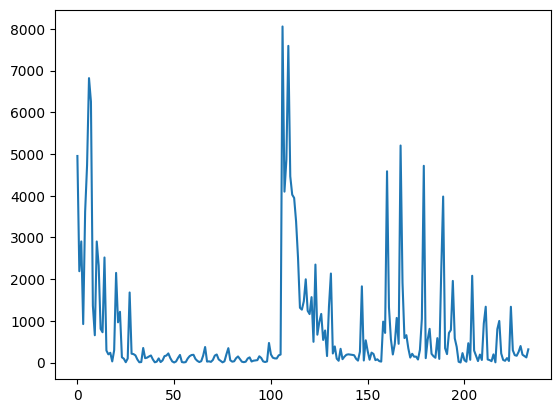

In [23]:
import matplotlib.pyplot as plt  
plt.plot(realtime_loss)

In [59]:
for index, loss in enumerate(realtime_loss):
    print(index, int(loss))

0 4952
1 2190
2 2904
3 922
4 3616
5 4732
6 6818
7 6256
8 1364
9 654
10 2902
11 2324
12 807
13 726
14 2519
15 289
16 197
17 234
18 27
19 294
20 2149
21 964
22 1217
23 126
24 92
25 8
26 97
27 1680
28 212
29 202
30 172
31 73
32 8
33 12
34 349
35 105
36 118
37 146
38 170
39 75
40 6
41 22
42 99
43 11
44 51
45 153
46 168
47 219
48 108
49 27
50 2
51 26
52 111
53 182
54 12
55 3
56 12
57 96
58 153
59 180
60 186
61 87
62 40
63 12
64 33
65 168
66 373
67 23
68 29
69 16
70 62
71 167
72 193
73 76
74 42
75 5
76 30
77 197
78 345
79 55
80 21
81 30
82 104
83 146
84 85
85 20
86 9
87 21
88 97
89 124
90 25
91 44
92 52
93 58
94 151
95 109
96 27
97 13
98 27
99 469
100 194
101 116
102 100
103 98
104 172
105 192
106 8057
107 4097
108 4864
109 7592
110 4465
111 4025
112 3946
113 3386
114 2516
115 1313
116 1268
117 1469
118 1996
119 1240
120 1161
121 1568
122 497
123 2349
124 668
125 971
126 1165
127 542
128 769
129 156
130 1353
131 2134
132 218
133 387
134 94
135 43
136 330
137 81
138 141
139 186
140 197
141 19

In [ ]:
# threshold = 250 for 3 or more iterations
import pandas as pd
# pd.DataFrame(focus_angles[0][1])
# len(focus_angles)
column = 10
pre = focus_angles[column][0]
act = focus_angles[column][1]
# pd.DataFrame({"predicted": pre,"actual":act})
pre, act, realtime_loss[column]

([[174.36646, 167.49007],
  [172.03207, 164.97961],
  [171.56335, 164.99898],
  [170.1102, 163.40337],
  [168.57686, 162.43102]],
 [[170.9386949807213, 179.06337845467843],
  [39.83366140905516, 178.0163766189564],
  [31.778475882497244, 177.80553522787264],
  [24.643111841862474, 178.0046921677763],
  [22.142294839256458, 178.5430714465146]],
 8057.244071571053)

In [49]:
import torch
import torch.nn as nn
# column = 58
pre = focus_angles[column][0]
act = focus_angles[column][1]

mae_loss = nn.MSELoss()
loss = mae_loss(torch.tensor(pre),torch.tensor(act))
loss.item()

153.39810012474135

In [44]:
len(focus_angles[0][0][0])
print(focus_angles[0][0])

[[ 65.80187988  54.31128693  42.76012039 157.05247498 160.69673157
  110.72728729  85.05117798]
 [ 62.40400696  57.0947876   41.29577255 152.31015015 156.61231995
  104.87754822  82.68431091]]


In [65]:
#this is for my check in output
print("Stored Predicted vs Real-Time Angle Pairs:")
for i, (pred, real) in enumerate(predicted_vs_real_storage):
    print(f"({pred}, {real})")

Stored Predicted vs Real-Time Angle Pairs:
([[ 63.719685  58.467083  45.11158  141.4796   132.05826   80.85753
   49.83015 ]
 [ 67.0671    60.59667   47.46817  144.5395   130.86485   84.96108
   54.234695]
 [ 69.2908    64.01208   42.269295 142.46451  128.55826   91.779976
   59.783836]
 [ 72.9347    66.287415  45.08512  144.27547  123.94408   98.29548
   65.262375]
 [ 75.28677   65.509384  46.114693 140.90938  123.31301  101.53889
   60.45671 ]
 [ 75.274254  67.64385   46.20072  133.46544  118.53572  102.75788
   54.759903]
 [ 73.28356   64.53964   44.492836 126.70815  115.83458  106.43192
   61.843124]
 [ 69.83277   60.134666  42.303844 126.14586  115.304344 104.25251
   66.39214 ]
 [ 66.385635  55.41769   41.424377 122.44459  115.23902  100.35649
   60.748344]
 [ 55.810825  46.388916  47.83487  118.97906  106.74332   94.706825
   62.61964 ]], [[44.71858153891649, 20.09965708749327, 17.997623096142167, 178.42094311129125, 177.13298543294573, 28.52548056807549, 6.940304686701801], [44

In [38]:
#slicing and storing specific angles pred and actual vales
focus_angles=np.array([[pred[3:5],real[3:5]]for pred,real in predicted_vs_real_storage])
print(focus_angles)

[[[[ 65.80187988  54.31128693  42.76012039 157.05247498 160.69673157
    110.72728729  85.05117798]
   [ 62.40400696  57.0947876   41.29577255 152.31015015 156.61231995
    104.87754822  82.68431091]]

  [[ 78.61124171  78.08135528  14.58289203 177.22901451 179.77967735
     53.74221918  49.23612362]
   [ 77.74181704  75.14642725  14.42657309 176.86984873 179.48244557
     52.34658113  45.85512251]]]


 [[[ 51.53899002 107.4981842   10.7578001  154.11595154 144.61502075
     49.96429825  71.21890259]
   [ 39.97299576  90.79743958  28.8418045  155.75950623 147.09791565
     62.33456802  63.3861351 ]]

  [[ 51.25260247  52.71046904  18.45846462 177.10301529 177.84279417
     26.68511481  25.17521687]
   [ 50.80930256  52.71998225  18.39934118 177.10909826 177.77798352
     26.25902433  25.0034717 ]]]


 [[[ 63.66189957  48.62889862  33.56424713 154.73138428 142.02282715
    112.09315491  81.65422821]
   [ 57.66621017  49.30174255  33.10097885 165.84849548 149.37483215
    114.52114105  7

In [ ]:
# #!/usr/bin/env python
 
# import cv2
# import time
 
# if __name__ == '__main__' :
 
#     # Start default camera
#     video = cv2.VideoCapture(0);
 
#     # Find OpenCV version
#     (major_ver, minor_ver, subminor_ver) = (cv2.__version__).split('.')
 
#     # With webcam get(CV_CAP_PROP_FPS) does not work.
#     # Let's see for ourselves.
 
#     if int(major_ver)  < 3 :
#         fps = video.get(cv2.cv.CV_CAP_PROP_FPS)
#         print("Frames per second using video.get(cv2.cv.CV_CAP_PROP_FPS): {0}".format(fps))
#     else :
#         fps = video.get(cv2.CAP_PROP_FPS)
#         print("Frames per second using video.get(cv2.CAP_PROP_FPS) : {0}".format(fps))
 
#     # Number of frames to capture
#     num_frames = 50;
 
#     print("Capturing {0} frames".format(num_frames))
 
#     # Start time
#     start = time.time()
 
#     # Grab a few frames
#     for i in range(0, num_frames) :
#         ret, frame = video.read()
 
#     # End time
#     end = time.time()
 
#     # Time elapsed
#     seconds = end - start
#     print ("Time taken : {0} seconds".format(seconds))
 
#     # Calculate frames per second
#     fps  = num_frames / seconds
#     print("Estimated frames per second : {0}".format(fps))
 
#     # Release video
#     video.release()

Frames per second using video.get(cv2.CAP_PROP_FPS) : 30.0
Capturing 50 frames
Time taken : 1.8902583122253418 seconds
Estimated frames per second : 26.451411257722004


# Make Basic Detection

In [3]:
# Getting video feed
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
    while cap.isOpened():
        ret, frame = cap.read()

        # Recolor image to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False 

        # Make detection
        results = pose.process(image)
        
        # Recolor back to BGR
        image.flags.writeable = True 
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Extract landmarks
        try:
            landmarks = results.pose_landmarks.landmark
            print(landmarks)
        except:
            pass

        # Rendering
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                                  mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                                  mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2),
                                  )

        cv2.imshow('Raw Webcam Feed', image)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# 2. Determining Joints

<img src="https://i.imgur.com/3j8BPdc.png" style="height:300px" >

In [4]:
landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value]

NameError: name 'landmarks' is not defined

In [ ]:
landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value]

x: 1.01653159
y: 0.86054343
z: -1.10317266
visibility: 0.545346856

# 3. Calculate Angles

In [5]:
def calculate_angle(a,b,c):
    a = np.array(a) # First
    b = np.array(b) # Mid
    c = np.array(c) # End
    
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    
    if angle >180.0:
        angle = 360-angle
        
    return angle 

In [6]:
shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
elbow = [landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].x,landmarks[mp_pose.PoseLandmark.LEFT_ELBOW.value].y]
wrist = [landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].x,landmarks[mp_pose.PoseLandmark.LEFT_WRIST.value].y]


NameError: name 'landmarks' is not defined

In [7]:
shoulder, elbow, wrist

NameError: name 'shoulder' is not defined

In [ ]:
calculate_angle(shoulder, elbow, wrist)

158.37397025964307

# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


# Holistic

In [ ]:
# mp_drawing = mp.solutions.drawing_utils
# mp_holistic = mp.solutions.holistic

In [ ]:
# import cv2
# import mediapipe as mp

# mp_drawing = mp.solutions.drawing_utils
# mp_drawing_styles = mp.solutions.drawing_styles
# mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh_connections  # Import face_mesh for FACE_CONNECTIONS

# cap = cv2.VideoCapture(0)

# # Initiate holistic model
# with mp_holistic.Holistic(min_detection_confidence=0.5, 
#                           min_tracking_confidence=0.5,
#                           static_image_mode=False,
#                           smooth_landmarks=True,
#                           model_complexity=2
#                             ) as holistic:
    
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor Feed
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False        
        
#         # Make Detections
#         results = holistic.process(image)
        
#         # Recolor image back to BGR for rendering
#         image.flags.writeable = True   
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         # 1. Draw face landmarks
#         mp_drawing.draw_landmarks(
#             image, results.face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,  # Use FACE_CONNECTIONS from face_mesh module
#             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
#             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
#         )
        
#         # 2. Right hand
#         mp_drawing.draw_landmarks(
#             image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
#         )

#         # 3. Left Hand
#         mp_drawing.draw_landmarks(
#             image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
#         )

#         # 4. Pose Detections
#         mp_drawing.draw_landmarks(
#             image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS, 
#             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
#         )
                        
#         cv2.imshow('Holistic Webcam Feed', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()


In [ ]:
# SPINE ANGLE

In [ ]:
# import cv2
# import mediapipe as mp
# import numpy as np

# mp_drawing = mp.solutions.drawing_utils
# mp_pose = mp.solutions.pose

# def calculate_angle(a, b, c):
#     a = np.array(a)  # First point  
#     b = np.array(b)  # Midpoint
#     c = np.array(c)  # End point
    
#     radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
#     angle = np.abs(radians * 180.0 / np.pi)
    
#     if angle > 180.0:
#         angle = 360 - angle
        
#     return angle

# cap = cv2.VideoCapture(0)

# with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5, model_complexity=2) as pose:
#     while cap.isOpened():
#         ret, frame = cap.read()
        
#         # Recolor image to RGB
#         image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         image.flags.writeable = False

#         # Make detection
#         results = pose.process(image)
        
#         # Recolor back to BGR
#         image.flags.writeable = True
#         image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
#         try:
#             landmarks = results.pose_landmarks.landmark

#             # Get coordinates for back straightness check
#             shoulder = [landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].x,
#                         landmarks[mp_pose.PoseLandmark.LEFT_SHOULDER.value].y]
#             hip = [landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].x,
#                    landmarks[mp_pose.PoseLandmark.LEFT_HIP.value].y]
#             knee = [landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].x,
#                     landmarks[mp_pose.PoseLandmark.LEFT_KNEE.value].y]
            
#             # Calculate angle for back straightness
#             spine_angle = calculate_angle(shoulder, hip, knee)
            
#             # Visualize spine angle
#             cv2.putText(image, f'Spine Angle: {int(spine_angle)}', 
#                         (50, 50), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)
            
#             # Get foot positions for feet check
#             left_heel_z = landmarks[mp_pose.PoseLandmark.LEFT_HEEL.value].z
#             right_heel_z = landmarks[mp_pose.PoseLandmark.RIGHT_HEEL.value].z
            
#             # Check if feet are lifting off the ground
#             if left_heel_z > 0.25 or right_heel_z > 0.25:  # Adjust threshold as needed
#                 cv2.putText(image, "Feet not planted!", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2, cv2.LINE_AA)
#             else:
#                 cv2.putText(image, "Feet planted", 
#                             (50, 100), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
                       
#         except:
#             pass
        
#         # Render detections
#         mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
#                                   mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4),
#                                   mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))
        
#         cv2.imshow('Squat Form Detection', image)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break

# cap.release()
# cv2.destroyAllWindows()
